<h1 style="text-align:center; font-size:42px; margin-top:40px;">

Analyse exploratoire – Profil des développeurs (Survey 2024)

</h1>


## 1. Contexte et objectif

Ce module explore le profil des répondants développeurs du Stack Overflow Developer Survey 2024.
Il vise à dresser un portrait global des participants en analysant :

- les caractéristiques démographiques (âge, pays, éducation) ;
- les secteurs d’activité et profils professionnels ;
- la répartition des statuts d’emploi ;
- la distribution des salaires ;
- les relations entre satisfaction professionnelle, expérience, salaire et mode de travail.

Les résultats obtenus serviront de base aux analyses technologiques, salariales et comportementales dans les notebooks suivants.

## 2. Librairies & chargement des données

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv("../Data/Survey/processed/survey-data_V3_final.csv")
df.head()

,ResponseId,MainBranch,Age,RemoteWork,Country,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,...,NEWCollabToolsHaveWorkedWith,AIToolCurrently Using,Country_valide,ExperienceLevel,Employed,Student,full_time,Independent,looking_for_work,Retired
0,1,I am a developer by profession,Under 18 years old,Remote,United States of America,Hobby,Primary/elementary school,Books / Physical media,NaN,NaN,...,NaN,NaN,True,junior,1,0,1,0,0,0
1,2,I am a developer by profession,35-44 years old,Remote,United Kingdom of Great Britain and Northern I...,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,...,PyCharm;Visual Studio Code;WebStorm,NaN,True,sénior,1,0,1,0,0,0
2,3,I am a developer by profession,45-54 years old,Remote,United Kingdom of Great Britain and Northern I...,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,...,Visual Studio,NaN,True,sénior,1,0,1,0,0,0
3,4,I am learning to code,18-24 years old,"Hybrid (some remote, some in-person)",Canada,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,NaN,...,NaN,Learning about a codebase;Project planning;Wri...,True,junior,0,1,1,0,0,0
4,5,I am a developer by profession,18-24 years old,"Hybrid (some remote, some in-person)",Norway,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,API document(s) and/or SDK document(s);User gu...,...,Vim,NaN,True,junior,0,1,1,0,0,0


## 3. Nombre total de répondants 

In [10]:
nbr_repondants=df["ResponseId"].nunique()
print("Nombre de Répondants", nbr_repondants)

Nombre de Répondants 61201


## 4. Analyse de l’âge

Les âges sont fournis sous forme de tranches textuelles (ex. "25–34 years old").
Pour obtenir une distribution exploitable, chaque tranche est convertie en centre numérique.

In [11]:
df["Age"].value_counts()

Age
25-34 years old       22535
35-44 years old       14435
18-24 years old       12500
45-54 years old        6142
55-64 years old        2556
Under 18 years old     1995
65 years or older       739
Prefer not to say       299
Name: count, dtype: int64

In [12]:
def search_center(txt):
    """ Calcule la moyenne de la plage d’âge, renvoie NaN si non renseigné. """
    import re
    import numpy as np
    numbers=[]
    numbers=re.findall(r"\d+\.?\d*",txt)
    if numbers:
        return np.mean(list(map(int,numbers)))
    else: return np.nan

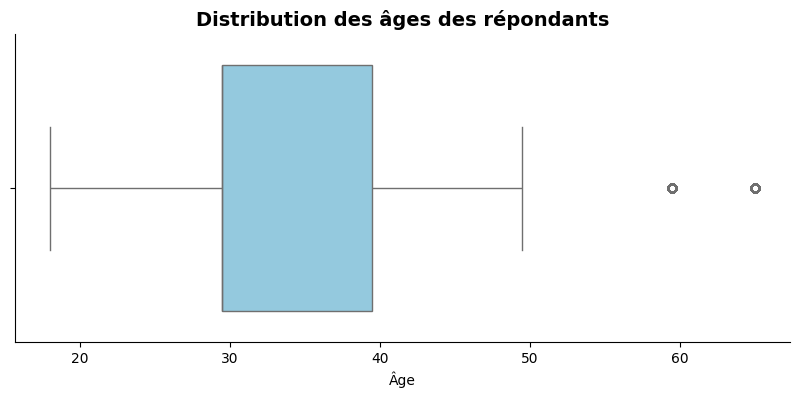

Caractéristique des ages: 
count    60902.0
mean        33.0
std         11.0
min         18.0
25%         30.0
50%         30.0
75%         40.0
max         65.0
Name: Age, dtype: float64


In [13]:
dt=df["Age"].apply(search_center).to_frame()
plt.figure(figsize=(10,4))
sns.boxplot(x=dt["Age"], color="skyblue")

plt.title("Distribution des âges des répondants", fontsize=14, fontweight="bold")
plt.xlabel("Âge")
sns.despine()
plt.savefig("../Reports/Figures/Profile/07_profile_age_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# Statistiques descriptives
print("Caractéristique des ages: ")
print( dt["Age"].describe().round())


#### Interprétation

- La majorité des répondants se situent entre 30 et 40 ans.
- La présence d’un grand nombre de répondants jeunes (18–24 ans) reflète l’entrée continue de nouveaux développeurs dans le secteur.
- Quelques valeurs extrêmes existent (50+), mais elles sont limitées.

## 5. Répartition géographique (Country)

### 5.1. Diversité géographique

In [14]:
print("Nombre de pays représentés : ",len(df[df["Country"].isna()==False]["Country"].unique()))

Nombre de pays représentés :  182


### 5.2. Top 10 des pays représentés

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8520\1532460874.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


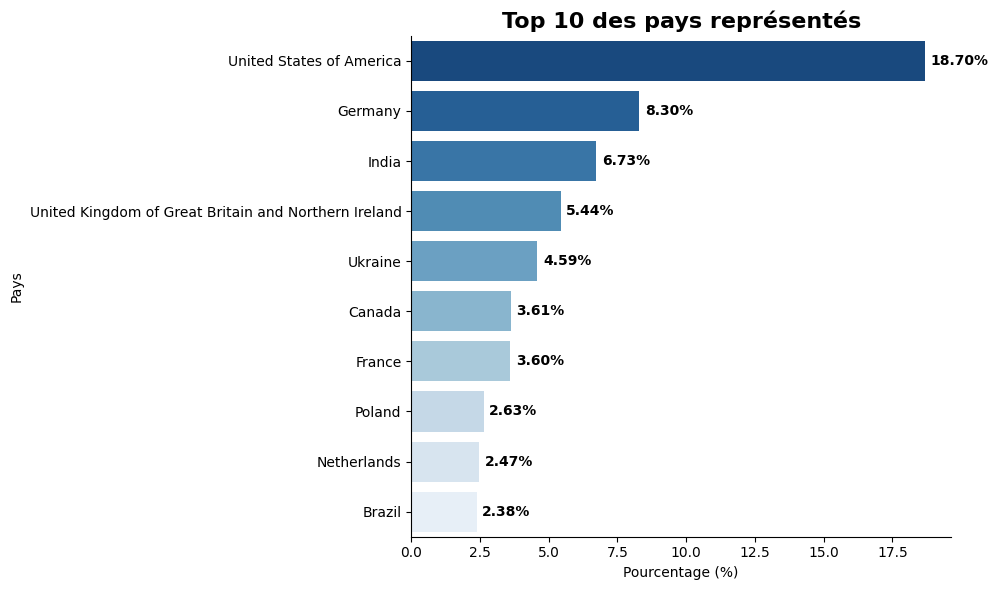

In [15]:
top_countries = (
    df["Country"]
    .value_counts(normalize=True)   # calcule automatiquement les %
    .head(10)
    * 100
).round(2)

plt.figure(figsize=(10,6))
ax = sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette="Blues_r",
   # hue=top_countries.values
)

# labels %
for i, v in enumerate(top_countries.values):
    ax.text(v + 0.2, i, f"{v:.2f}%", va="center", fontweight="bold")

plt.title("Top 10 des pays représentés", fontsize=16, fontweight="bold")
plt.xlabel("Pourcentage (%)")
plt.ylabel("Pays")

sns.despine()
plt.tight_layout()
plt.savefig("../Reports/Figures/Profile/07_profile_top10_countries.png", dpi=300, bbox_inches='tight')

plt.show()


#### Interprétation
* Les États-Unis, l’Inde et l’Allemagne concentrent la majorité des répondants.
* Le top 10 représente une large portion du dataset : la communauté reste très occidentale avec une forte présence Asie du Sud.
* La variété des pays offre une bonne diversité culturelle et professionnelle pour les analyses globales.

## 6. Secteurs d’activité (Industry)

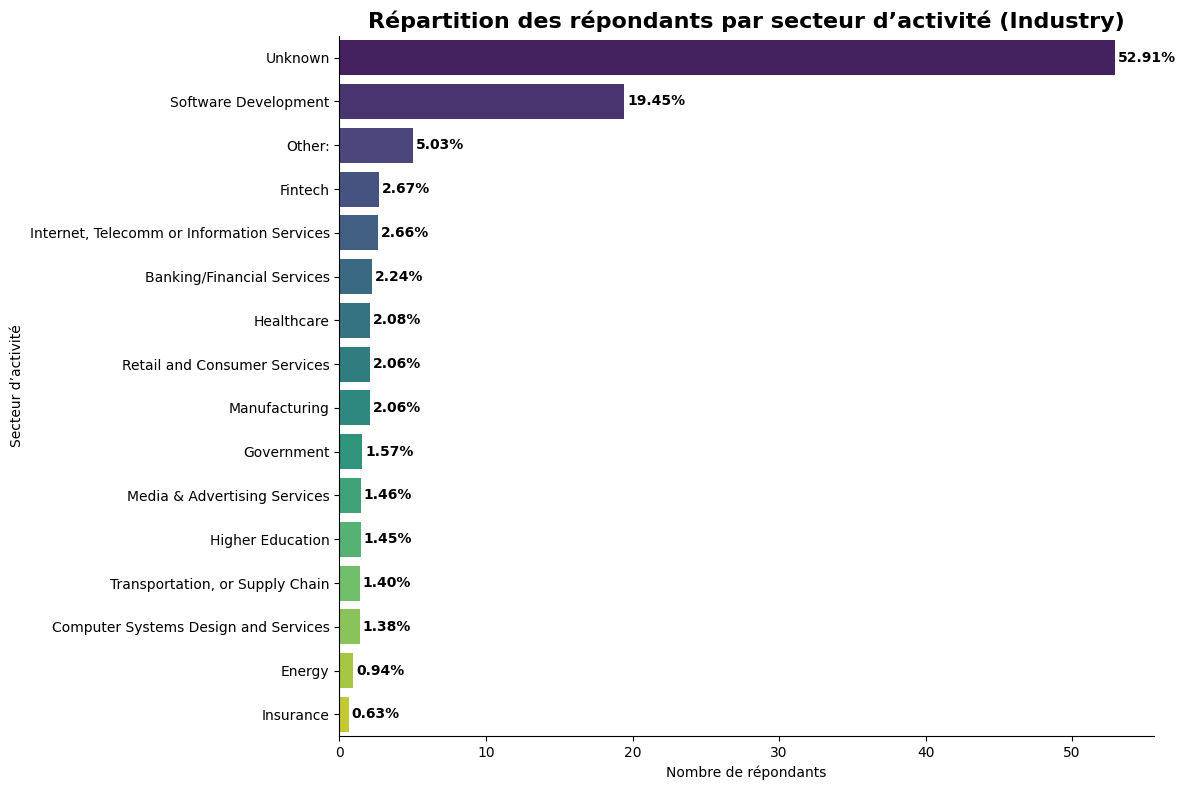

In [16]:
# Comptage des valeurs (NaN regroupés sous "Unknown")
industry_counts = (df["Industry"].value_counts(normalize=True)*100).round(2)

plt.figure(figsize=(12,8))
ax = sns.barplot(
    x=industry_counts.values,
    y=industry_counts.index,
    palette="viridis",
    hue=industry_counts.index,
    dodge=False,
    legend=False
)

# Ajouter les valeurs sur les barres
for i, v in enumerate(industry_counts.values):
    ax.text(v + 0.2, i, f"{v:.2f}%", va="center", fontweight="bold")


plt.title("Répartition des répondants par secteur d’activité (Industry)", 
          fontsize=16, fontweight="bold")
plt.xlabel("Nombre de répondants")
plt.ylabel("Secteur d’activité")

plt.subplots_adjust(left=0.3)
sns.despine()
plt.tight_layout()
plt.savefig("../Reports/Figures/Profile/07_profile_industry_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


#### Interprétation

* Les secteurs les plus représentés sont : software, finance, consulting, IT services.
* Les secteurs très spécialisés (énergie, santé, éducation) restent minoritaires mais existent.
* La catégorie "Unknown" absorbe une large part des réponses non renseignées.

## 7. Niveau d’éducation (EdLevel)

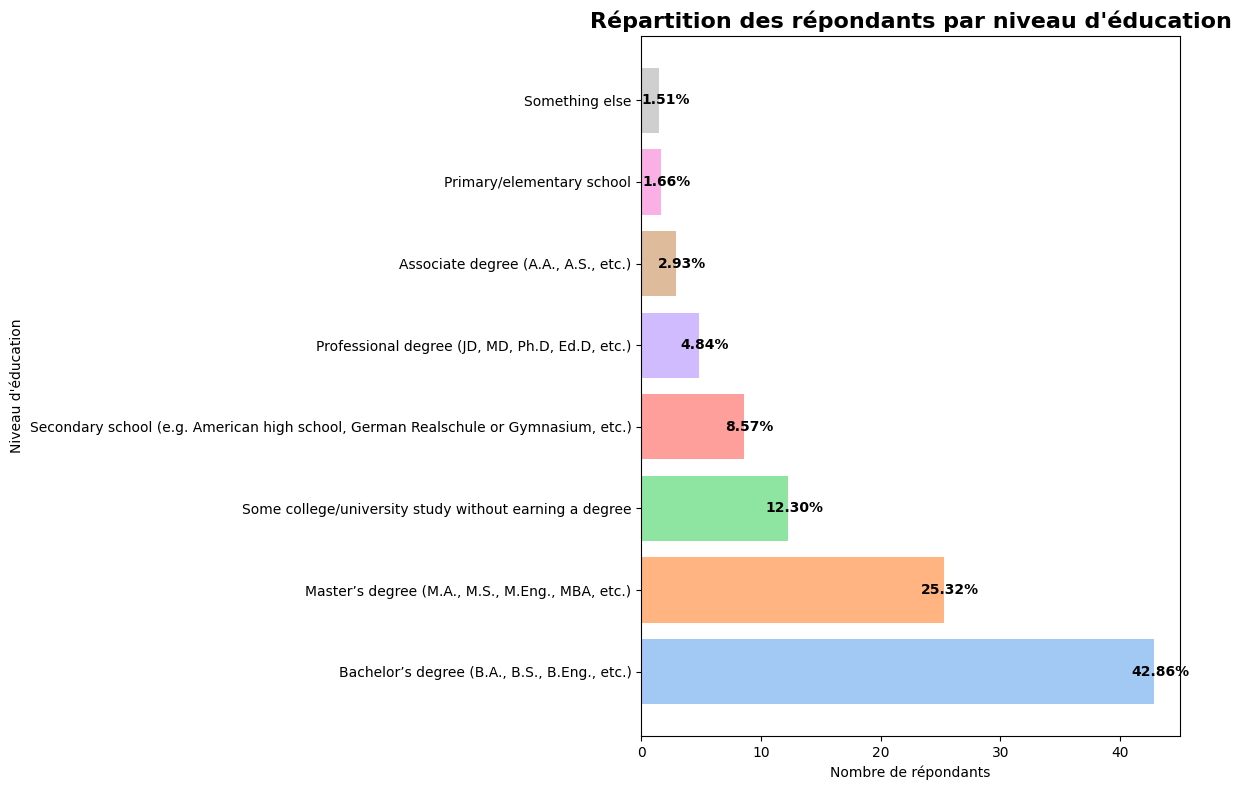

In [17]:
df_level=(df["EdLevel"].value_counts(normalize=True)*100).round(2)

plt.figure(figsize=(12,8))
colors = sns.color_palette("pastel")

ax = plt.barh(df_level.index, df_level.values, color=colors)

# Ajouter les labels au centre des barres
for i, v in enumerate(df_level.values):
    plt.text(v+0.5, i,f"{v:.2f}%", ha="center", va="center", fontweight="bold")

plt.title("Répartition des répondants par niveau d'éducation", fontsize=16, fontweight="bold")
plt.xlabel("Nombre de répondants")
plt.ylabel("Niveau d'éducation")
plt.tight_layout()
plt.savefig("../Reports/Figures/Profile/07_profile_education_level.png", dpi=300, bbox_inches='tight')
plt.show()


#### Interprétation

* Les niveaux Bachelor et Master dominent largement.
* Les diplômes professionnels / certificats représentent une part non négligeable — cohérent avec un secteur ouvert aux autodidactes.

## 8. Profil développeur (MainBranch)

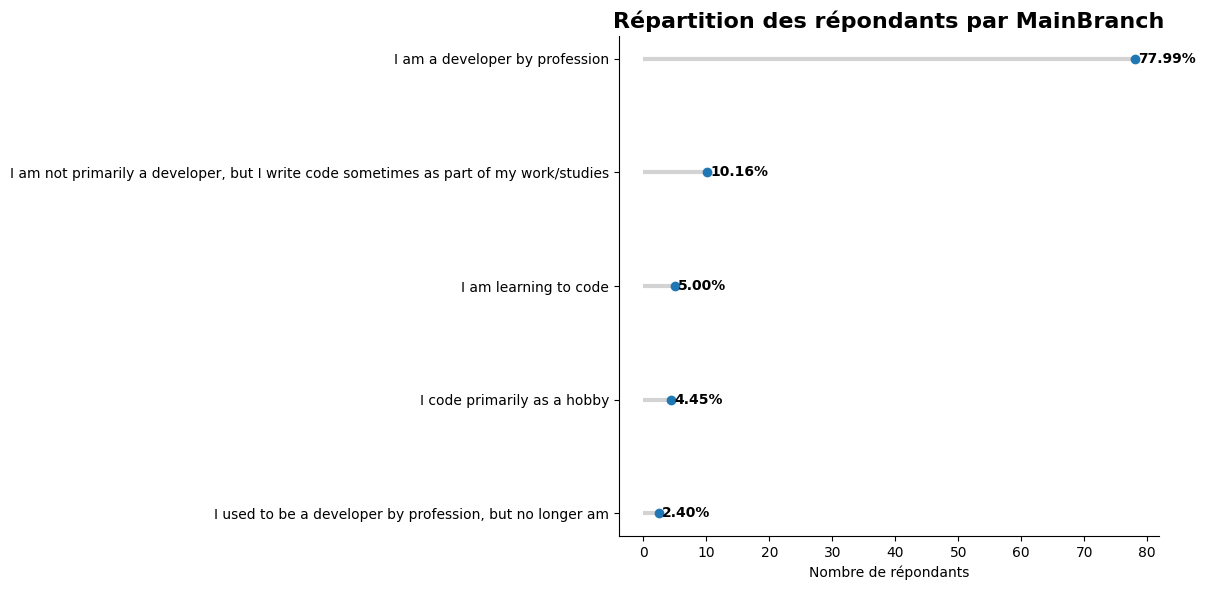

In [18]:
df_mb = (df["MainBranch"].value_counts(normalize=True).sort_values()*100).round(2)

plt.figure(figsize=(12,6))

plt.hlines(y=df_mb.index, xmin=0, xmax=df_mb.values, color="lightgray", linewidth=3)
plt.plot(df_mb.values, df_mb.index, "o", color="#1f77b4")

# Ajout des labels légèrement décalés
for cat, val in df_mb.items():
    plt.text(val + 0.5, cat, f"{val:.2f}%", va="center", fontsize=10, fontweight="bold")

plt.title("Répartition des répondants par MainBranch", fontsize=16, fontweight="bold")
plt.xlabel("Nombre de répondants")

sns.despine()
plt.tight_layout()
plt.savefig("../Reports/Figures/Profile/07_profile_mainbranch_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


Interprétation

* La très grande majorité des répondants se déclarent développeurs professionnels, suivis d’un groupe plus réduit qui code dans le cadre de leurs études ou de leur travail. 
* Les personnes en apprentissage, les hobbyistes et les anciens développeurs représentent des parts beaucoup plus faibles.

Le dataset reflète principalement le point de vue de développeurs actifs, ce qui renforce la pertinence des analyses techniques qui suivront.

## 9. Statuts professionnels (Employment) selon l’éducation

In [19]:
dt=df.groupby("EdLevel")[["Employed","Student","Independent","Retired"]].sum()
dt_pct = dt.div(dt.sum(axis=1), axis=0) * 100
dt_pct = dt_pct.round(2)
dt_pct


,Employed,Student,Independent,Retired
EdLevel,,,,
"Associate degree (A.A., A.S., etc.)",68.67,14.01,16.17,1.15
"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",73.99,10.58,14.72,0.72
"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",77.77,5.45,15.92,0.86
Primary/elementary school,27.96,54.59,16.22,1.22
"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",77.06,4.14,15.32,3.48
"Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)",41.14,43.29,15.16,0.40
Some college/university study without earning a degree,58.65,21.40,18.76,1.19
Something else,57.11,24.52,16.24,2.13


<Figure size 1400x800 with 0 Axes>

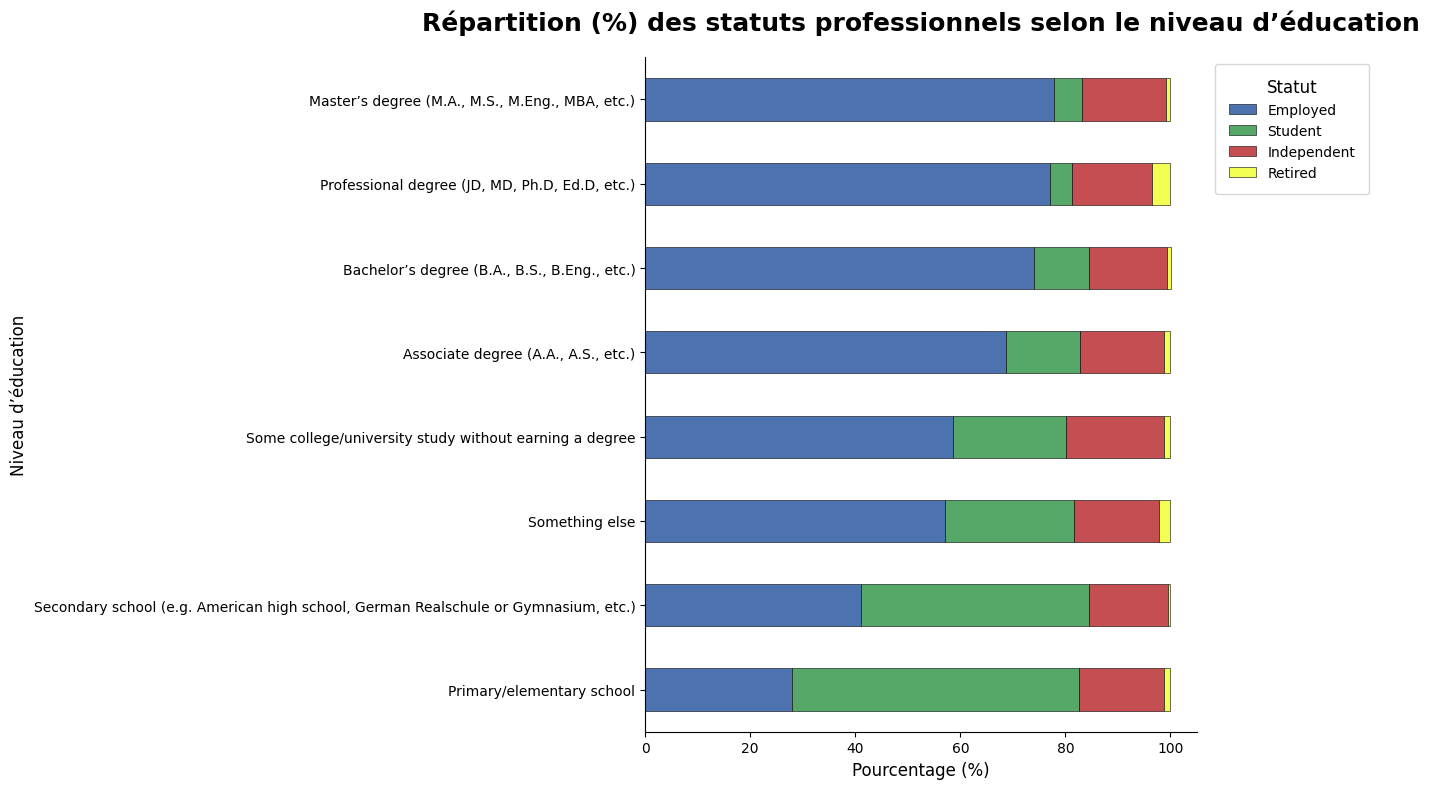

In [20]:
# Tri par pourcentage d'employés
dt_pct = dt_pct.sort_values("Employed", ascending=True)

plt.figure(figsize=(14, 8))

colors = ["#4C72B0", "#55A868", "#C44E52", "#f4ff54"]

dt_pct.plot(
    kind="barh",
    stacked=True,
    figsize=(14, 8),
    color=colors,
    edgecolor="black",
    linewidth=0.4
)

plt.title(
    "Répartition (%) des statuts professionnels selon le niveau d’éducation",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Pourcentage (%)", fontsize=12)
plt.ylabel("Niveau d’éducation", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.legend(
    title="Statut",
    title_fontsize=12,
    fontsize=10,
    bbox_to_anchor=(1.02, 1),
    borderpad=1
)

sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.savefig("../Reports/Figures/Profile/07_profile_employment_by_education.png", dpi=300, bbox_inches='tight')
plt.show()


#### Interpretation 

* Les personnes titulaires d’un diplôme élevé (Bachelor/Master) sont majoritairement en emploi.
* Les étudiants sont surtout regroupés dans les niveaux d’éducation intermédiaires.
* Les indépendants restent minoritaires mais très présents chez les diplômés supérieurs.
* Le niveau d’éducation influence fortement le statut d’emploi.


## 10. Statuts professionnels selon le mode de travail (RemoteWork)

In [21]:
dt=df.groupby("RemoteWork")[["Employed","Student","Independent","Independent"]].sum()
dt_pct = dt.div(dt.sum(axis=1), axis=0) * 100
dt_pct = dt_pct.round(2)
dt_pct

,Employed,Student,Independent,Independent
RemoteWork,,,,
"Hybrid (some remote, some in-person)",59.58,20.33,10.04,10.04
In-person,76.71,9.44,6.93,6.93
Remote,53.98,4.61,20.70,20.70


<Figure size 1200x600 with 0 Axes>

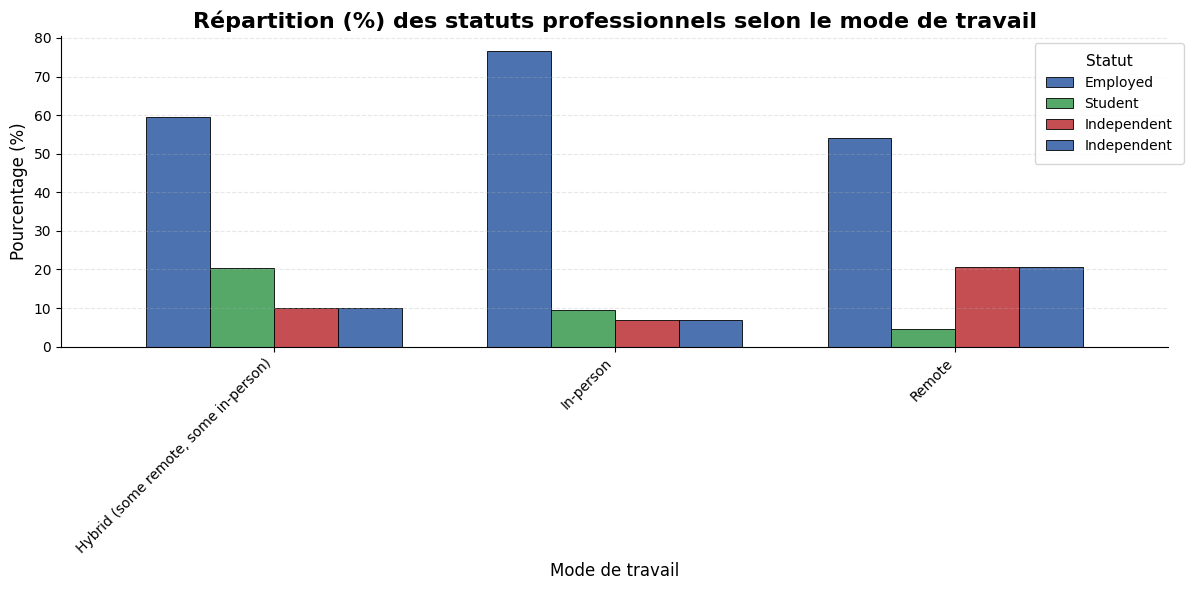

In [22]:
# Calcul des pourcentages par mode de travail
plt.figure(figsize=(12, 6))

dt_pct.plot(
    kind="bar",
    figsize=(12, 6),
    edgecolor="black",
    linewidth=0.6,
    color=["#4C72B0", "#55A868", "#C44E52"],
    width=0.75
)

plt.title(
    "Répartition (%) des statuts professionnels selon le mode de travail",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Mode de travail", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

plt.legend(
    title="Statut",
    title_fontsize=11,
    fontsize=10,
    bbox_to_anchor=(1.02, 1),
    borderpad=0.8
)

plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.savefig("../Reports/Figures/Profile/07_profile_employment_by_remote_mode.png", dpi=300, bbox_inches='tight')
plt.show()


#### Interprétation

* Les salariés travaillent majoritairement en Remote ou Hybrid, car la plupart des entreprises du secteur technologique ont adopté ces modèles comme standard de fonctionnement.
* Les étudiants se retrouvent surtout en Hybrid, un mode compatible avec les cours en présentiel, les projets personnels et les activités en ligne.
* Les indépendants sont clairement Remote-first, privilégiant presque exclusivement le travail à distance pour bénéficier de flexibilité et pouvoir collaborer avec des clients internationaux.
* Le mode In-person est minoritaire dans toutes les catégories, confirmant une transition massive vers des modèles de travail flexibles.

## 11. Analyse de la distribution des salaires

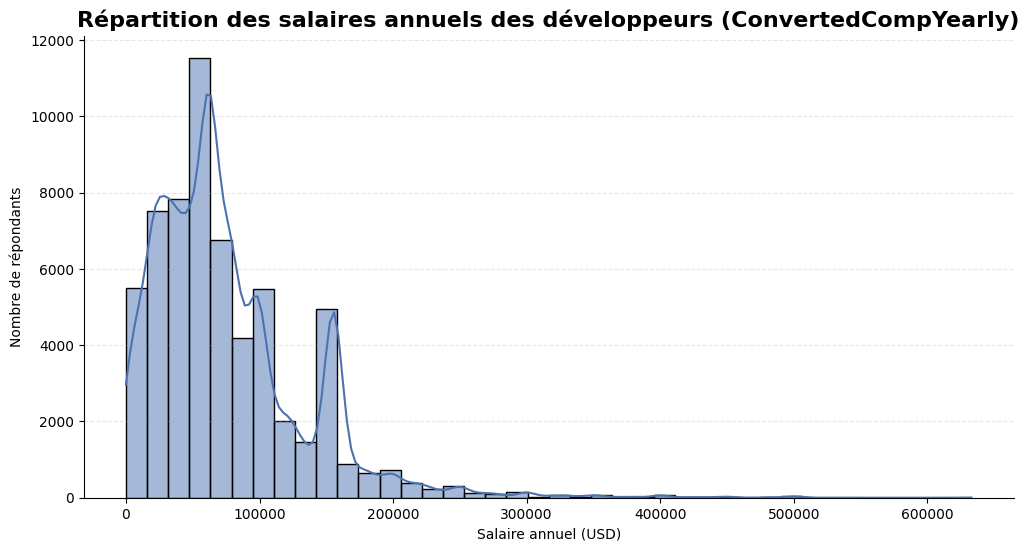

In [23]:
plt.figure(figsize=(12,6))

sns.histplot(
    df["ConvertedCompYearly"],
    kde=True,
    bins=40,
    color="#4C72B0"
)

plt.title("Répartition des salaires annuels des développeurs (ConvertedCompYearly)", 
          fontsize=16, fontweight="bold")
plt.xlabel("Salaire annuel (USD)")
plt.ylabel("Nombre de répondants")

plt.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()
plt.savefig("../Reports/Figures/Profile/07_profile_salary_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


#### Interprétation

La distribution des salaires annuels est fortement asymétrique : la majorité des développeurs gagne entre 40 000 et 120 000 USD, tandis qu’une petite minorité touche des salaires nettement plus élevés, ce qui étire la courbe vers la droite. La KDE confirme cette concentration autour d’un noyau central et la présence d’outliers très bien rémunérés. En clair : la plupart ont un salaire “classique”, et seuls quelques profils très spécialisés tirent la moyenne vers le haut.

## 12. Satisfaction professionnelle (JobSat)

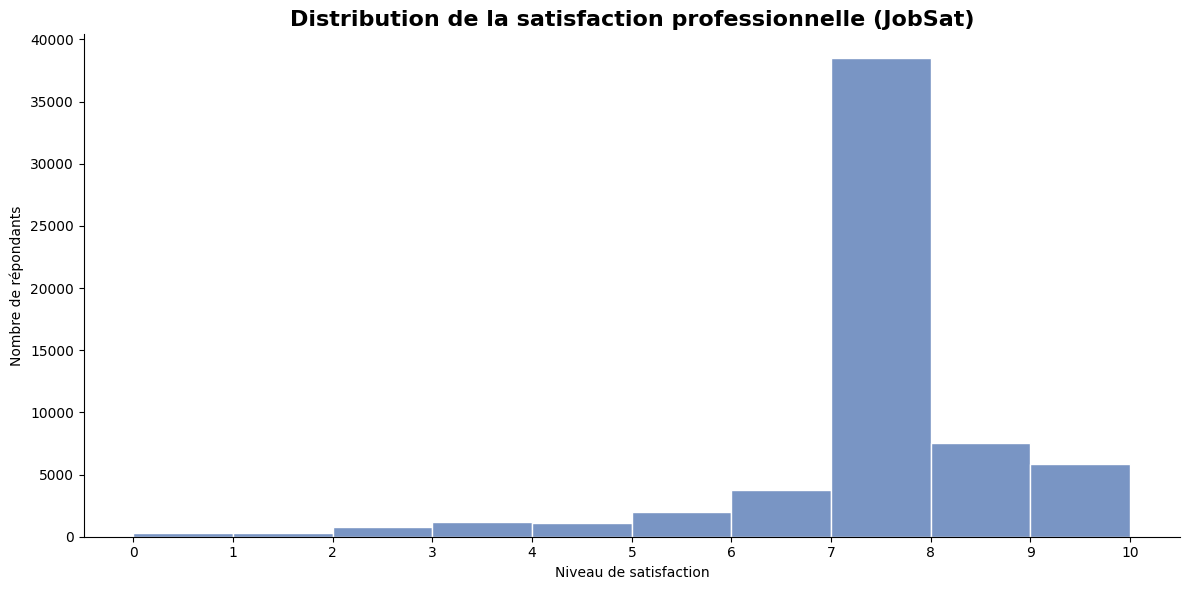

In [24]:
plt.figure(figsize=(12,6))

sns.histplot(
    df["JobSat"].dropna(),
    bins=10,                  # un bin par niveau de satisfaction
    kde=False,               
    color="#4C72B0",
    edgecolor="white"
)

plt.title("Distribution de la satisfaction professionnelle (JobSat)", 
          fontsize=16, fontweight="bold")
plt.xlabel("Niveau de satisfaction")
plt.ylabel("Nombre de répondants")

plt.xticks(range(0, 11))     # force l’affichage des niveaux 0 → 10
sns.despine()
plt.tight_layout()
plt.savefig("../Reports/Figures/Profile/07_profile_jobsat_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


#### Interprétation

* La plupart des développeurs se situent entre 6 et 8.
* Très peu de réponses <3 → globalement, la satisfaction est positive.

## 13. Satisfaction vs Niveau d’expérience (ExperienceLevel)

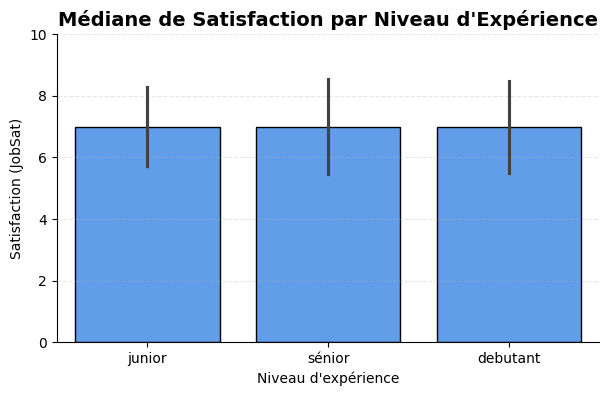

In [25]:
plt.figure(figsize=(7,4))
sns.barplot(
    data=df,
    x="ExperienceLevel",
    y="JobSat",
    estimator="median",
    errorbar="sd",
    color="#4C9AFF",
    edgecolor="black"
)

plt.title("Médiane de Satisfaction par Niveau d'Expérience", fontsize=14, fontweight="bold")
plt.xlabel("Niveau d'expérience")
plt.ylabel("Satisfaction (JobSat)")
plt.ylim(0,10)
plt.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()
plt.savefig("../Reports/Figures/Profile/07_profile_jobsat_by_experience.png", dpi=300, bbox_inches='tight')
plt.show()


#### Interprétation

* Les niveaux débutant, junior et sénior ont une médiane quasi identique (~7).
* L’expérience n’est pas un facteur majeur de satisfaction.
* Ce résultat suggère que des variables comme salaire, mode de travail, environnement, charge de travail influencent davantage la satisfaction.

## 14. Satisfaction vs Salaire

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8520\464271545.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


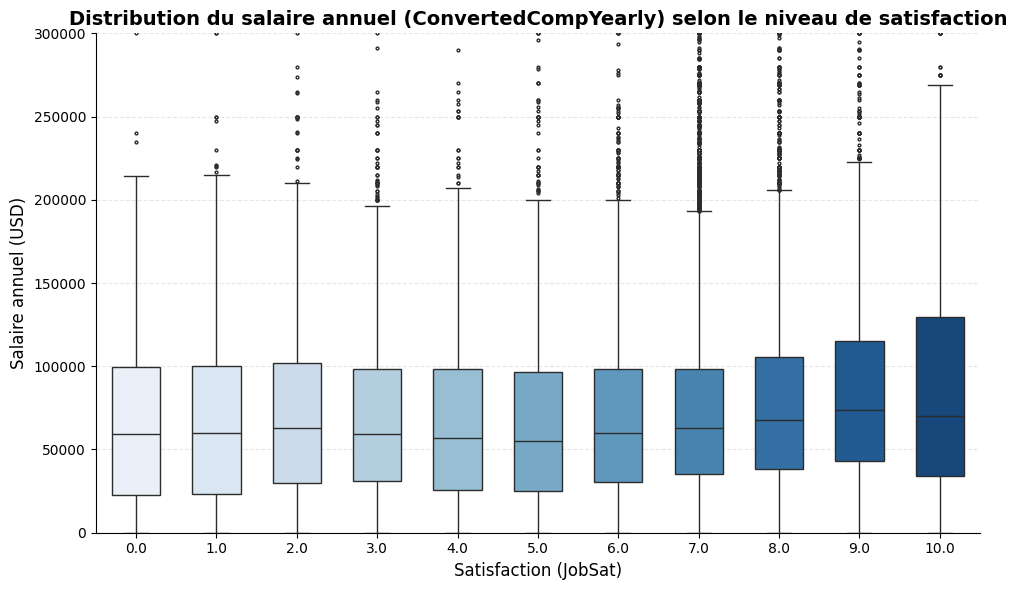

In [26]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="JobSat",
    y="ConvertedCompYearly",
    palette="Blues",
    width=0.6,
    fliersize=2
)

plt.title("Distribution du salaire annuel (ConvertedCompYearly) selon le niveau de satisfaction", 
          fontsize=14, fontweight="bold")
plt.xlabel("Satisfaction (JobSat)", fontsize=12)
plt.ylabel("Salaire annuel (USD)", fontsize=12)
plt.ylim(0, 300000)

plt.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig("../Reports/Figures/Profile/07_profile_salary_by_jobsat_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()



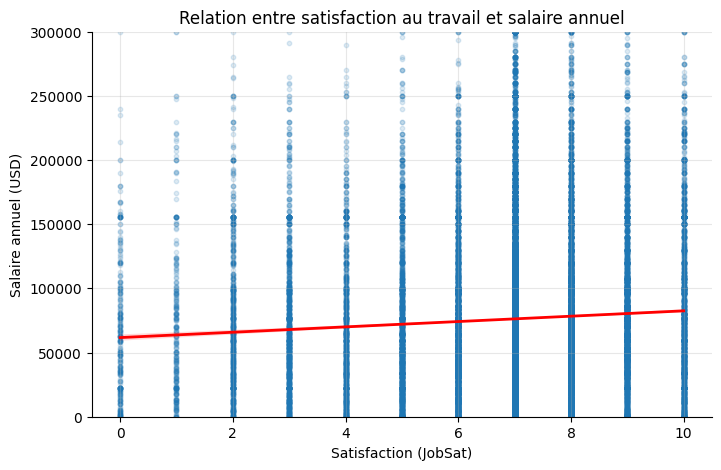

In [27]:
plt.figure(figsize=(8,5))
sns.regplot(
    data=df,
    x="JobSat",
    y="ConvertedCompYearly",
    scatter_kws={"alpha":0.15, "s":10},
    line_kws={"color":"red", "linewidth":2}
)

plt.title("Relation entre satisfaction au travail et salaire annuel")
plt.xlabel("Satisfaction (JobSat)")
plt.ylabel("Salaire annuel (USD)")
plt.ylim(0, 300000)  # ajuster si nécessaire
plt.grid(alpha=0.3)
sns.despine()
plt.savefig("../Reports/Figures/Profile/07_profile_salary_by_jobsat_regression.png", dpi=300, bbox_inches='tight')
plt.show()


#### Interprétation

* La relation entre satisfaction au travail et salaire est positive mais faible.
* Les employés plus satisfaits ont en moyenne un salaire légèrement plus élevé, mais la distribution montre une forte hétérogénéité.
* Le salaire n’est pas un bon prédicteur de la satisfaction, ce qui suggère que d’autres facteurs non financiers jouent un rôle majeur dans la satisfaction professionnelle.

## 15. Satisfaction vs Mode de travail (RemoteWork)

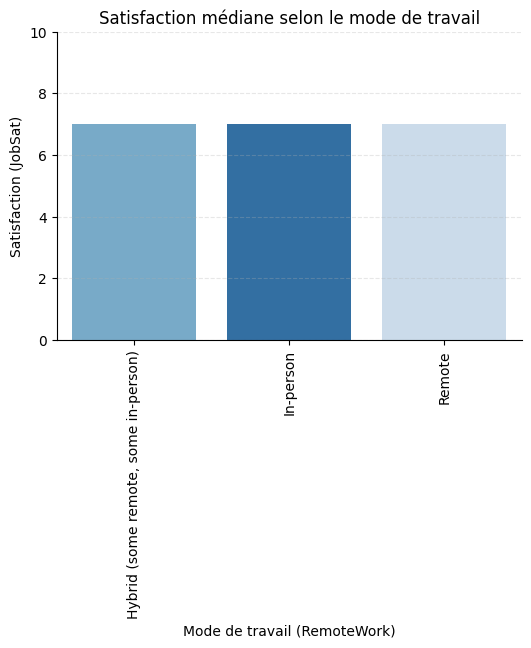

In [28]:
plt.figure(figsize=(6,4))
order = df.groupby("RemoteWork")["JobSat"].median().sort_values(ascending=False).index

ax = sns.barplot(
    data=df,
    x="RemoteWork",
    y="JobSat",
    order=order,
    estimator="median",
    errorbar=None,
    hue="RemoteWork",
    palette="Blues",orient="v"
)


plt.title("Satisfaction médiane selon le mode de travail")
plt.xlabel("Mode de travail (RemoteWork)")
plt.ylabel("Satisfaction (JobSat)")
plt.ylim(0,10)
plt.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()
plt.xticks(rotation=90)
plt.savefig("../Reports/Figures/Profile/07_profile_jobsat_by_remote_mode.png", dpi=300, bbox_inches='tight')
plt.show()


#### Interprétation

La satisfaction médiane est pratiquement identique entre les trois modes de travail.
Remote, Hybrid et In-person affichent tous un niveau autour de 7, ce qui montre que le mode de travail n’a qu’un impact limité sur la satisfaction globale.
En d’autres termes : les développeurs sont globalement satisfaits quel que soit leur mode de travail, et les différences entre groupes sont faibles.

## 16. Résumé

L’analyse du profil des développeurs du Survey 2024 met en évidence plusieurs tendances structurantes :

* **Population majoritairement professionnelle** : la grande majorité des répondants sont des développeurs actifs, ce qui donne au dataset une forte crédibilité pour l’analyse technique.

* **Profil démographique clair** : la majorité a entre 25 et 34 ans, avec une forte représentation des États-Unis, de l’Inde et de l’Europe.

* **Niveaux d’éducation élevés** : les diplômes Bachelor et Master dominent nettement, renforçant l’idée d’un secteur qualifié.

* **Modes de travail flexibles** : Remote et Hybrid sont les modèles les plus répandus chez les salariés et les indépendants.

* **Distribution salariale asymétrique** : la plupart gagnent entre 40k et 120k USD, avec une minorité très bien rémunérée qui tire les valeurs vers le haut.

* **Satisfaction professionnelle globalement positive** : médiane autour de 7, relativement stable selon l’expérience, le salaire et le mode de travail.

Au final, ce dataset décrit une communauté majoritairement composée de développeurs professionnels, jeunes, qualifiés, satisfaits de leur travail, et travaillant dans un environnement largement orienté vers le Remote/Hybrid – un portrait fidèle du secteur technologique actuel.

